In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [11]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from src.cnn_lstm.cnn_lstm_v3 import CNNLSTMV3
from src.XAI.gradcam import GradCAM
from src.XAI.SepConvlstm_gradcam import SepConvLSTMGradCam
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_heatmap_over_rgb, animate_saliency_over_rgb
from scripts.common.get_device import get_available_device

experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V4" / "final_systematic_search_2" / "h64_d0.35_wd2e-05_ls0.1"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

model = CNNLSTMV3(
    hidden_channels=hyperparameters["hidden_channels"],
    reduced_channels=hyperparameters["reduced_channels"],
    classifier_hidden_size=hyperparameters["classifier_hidden_size"],
    dropout=hyperparameters["dropout"],
    cnn_cutoff=hyperparameters["cnn_cutoff"],
    cnn_unfreeze_from=hyperparameters["cnn_unfreeze_from"], 
    pooling_mode=hyperparameters.get("pooling_mode", "double")
).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

dataset = RWF2000Dataset(
    DATASET_ROOT, 
    num_frames=hyperparameters["num_frames"], 
    input_mode=hyperparameters["input_mode"], 
    augment=False, 
    split="val", 
    return_rgb_frames=True
)

video_num = 7
video, label, rgb_frames = dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 32, 3, 224, 224]

label = label.item()

with torch.inference_mode():
    prediction = model(video_batch).argmax(dim=1).item()

Using cuda:4 with 20.20 GB free


In [12]:
# final layer of mobilenetv2
gradcam = GradCAM(model, model.cnn[-1], normalisation_mode='per_video')
heatmap = gradcam.generate_heatmap(video_batch)
gradcam.remove_hooks()


In [13]:
# sepconv lstm
sepconv_gradcam = SepConvLSTMGradCam(model, model.sepconvlstm, normalisation_mode='per_video')
heatmap_sepconv = sepconv_gradcam.generate_heatmap(video_batch)
sepconv_gradcam.remove_hooks()

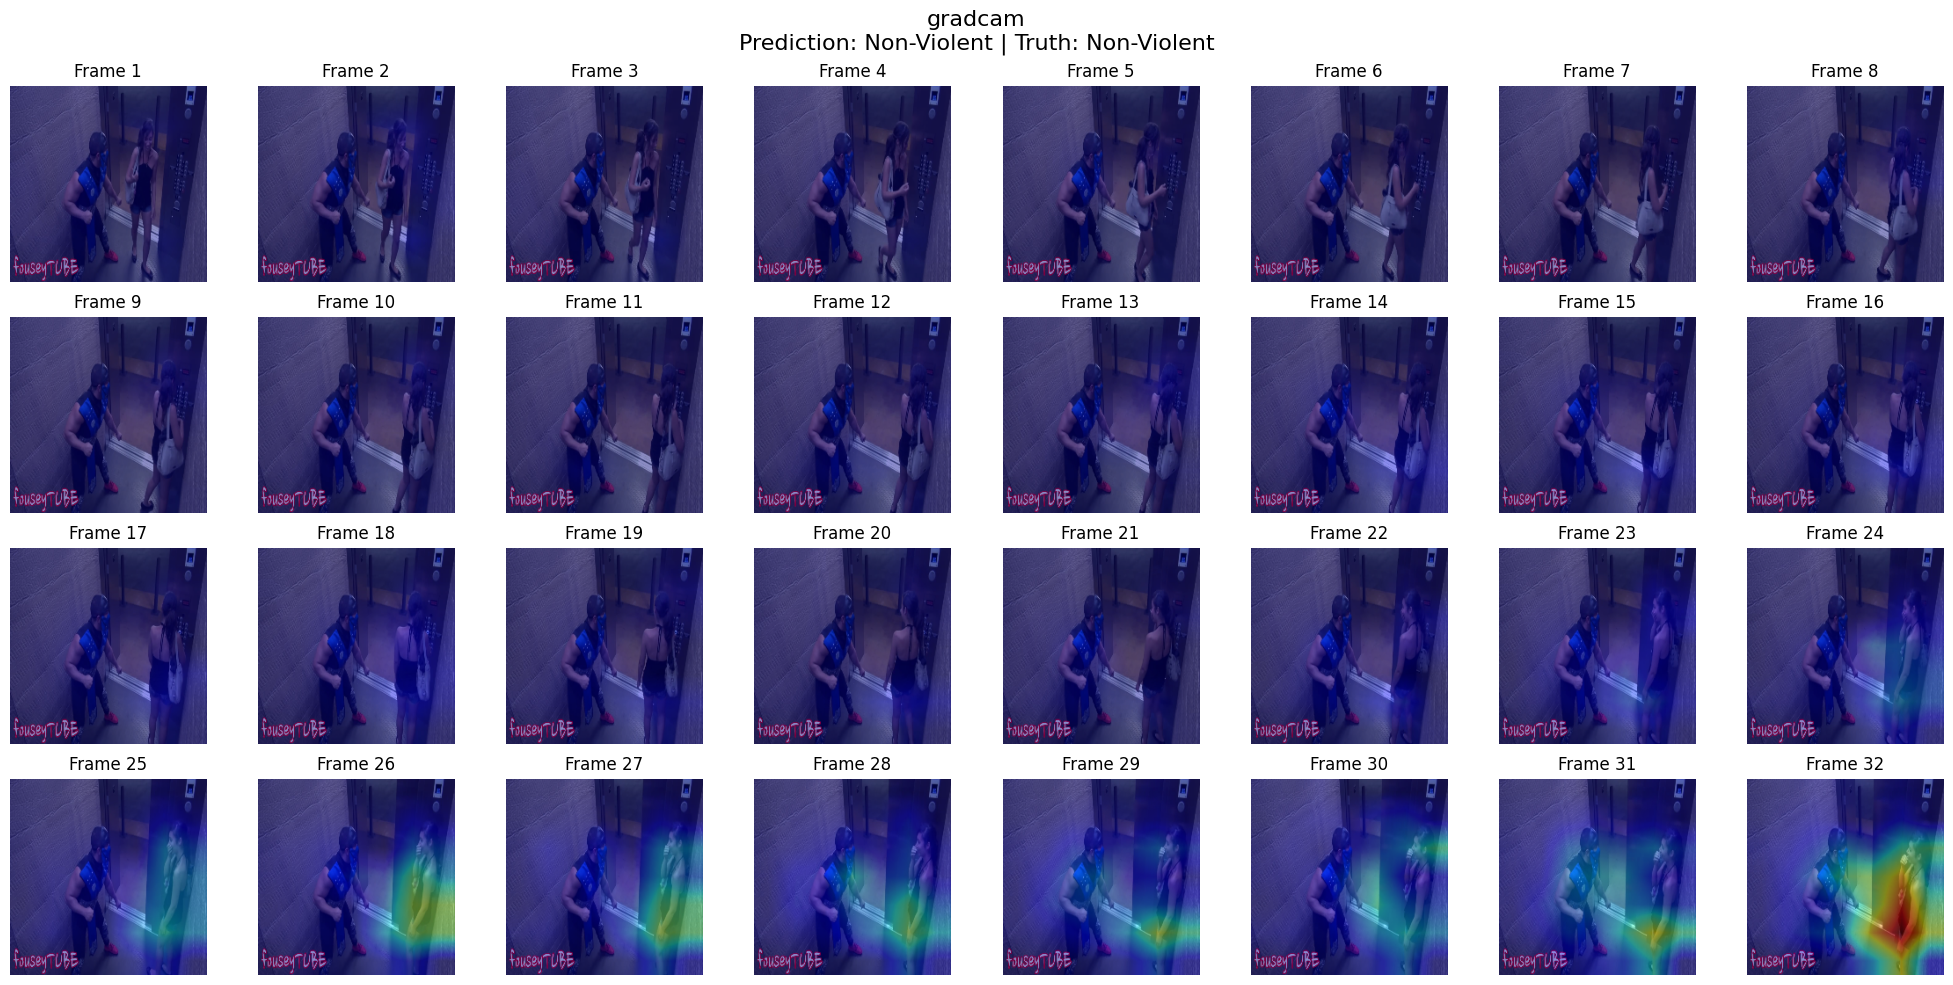

In [14]:
plot_heatmap_over_rgb(heatmap, rgb_frames, label, prediction)

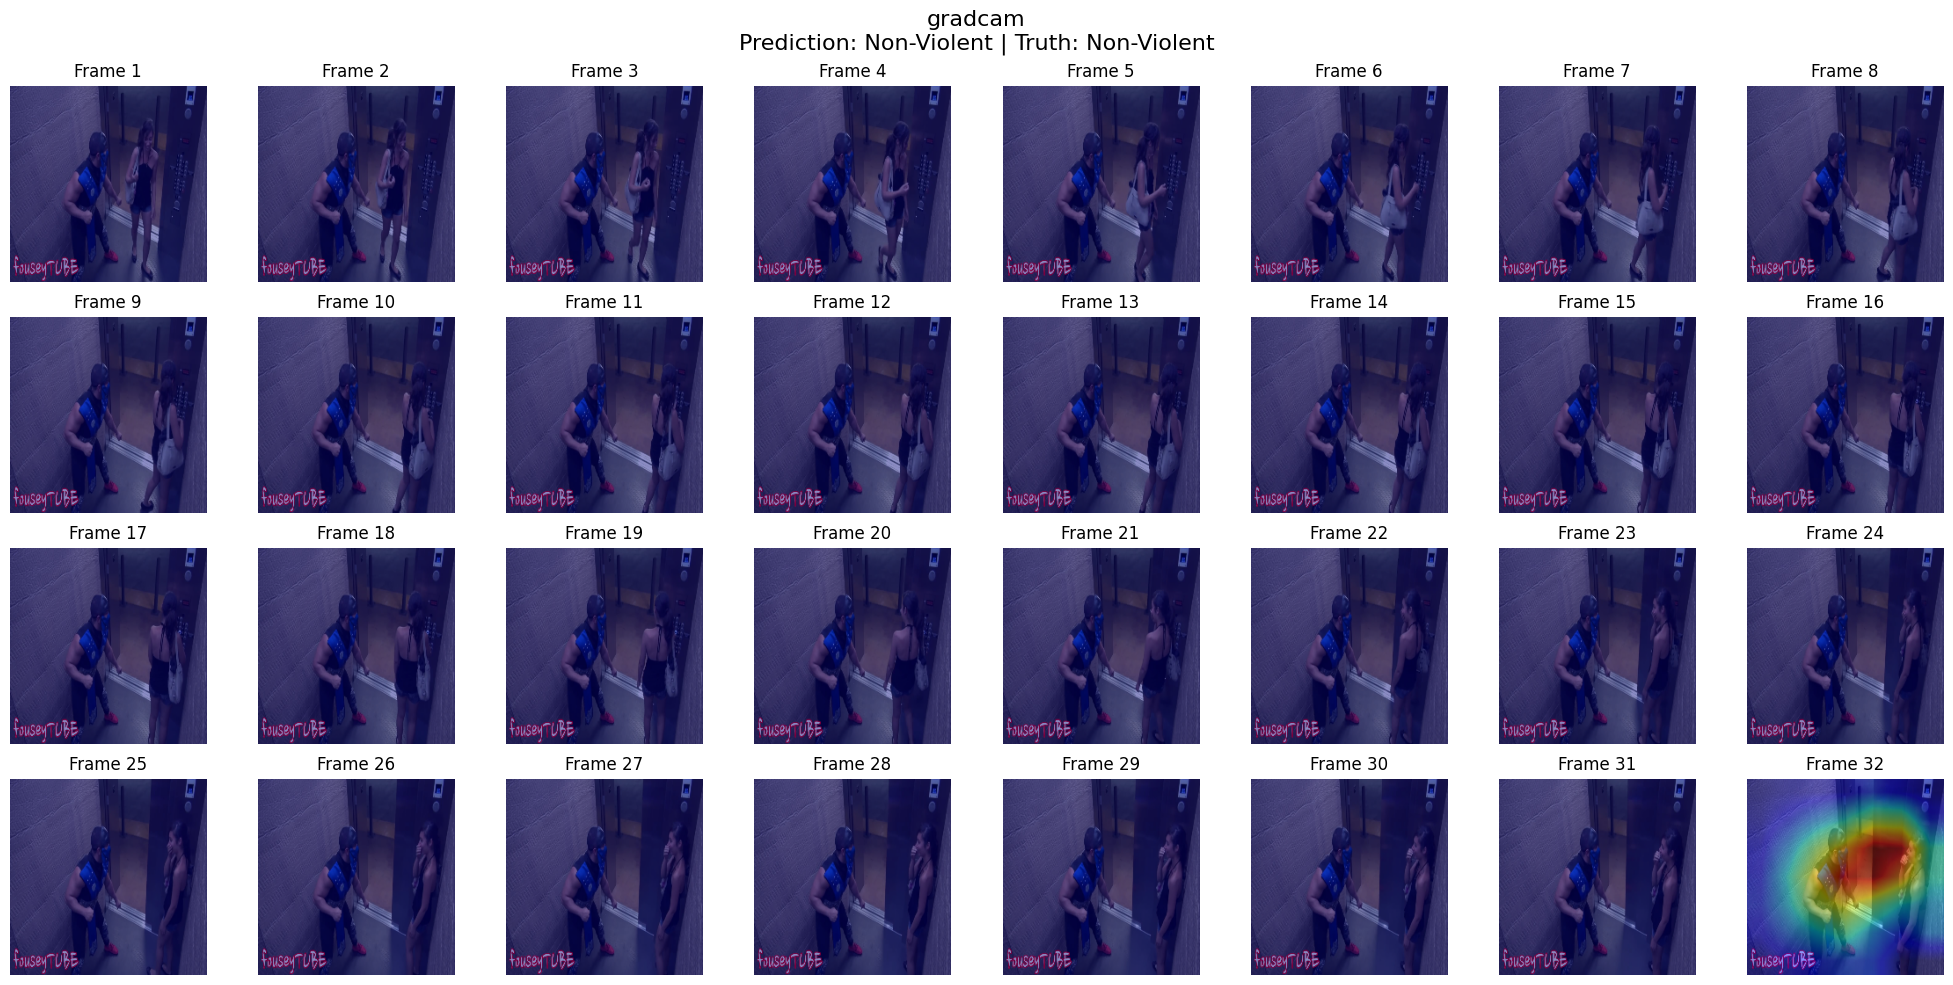

In [15]:
plot_heatmap_over_rgb(heatmap_sepconv, rgb_frames, label, prediction)

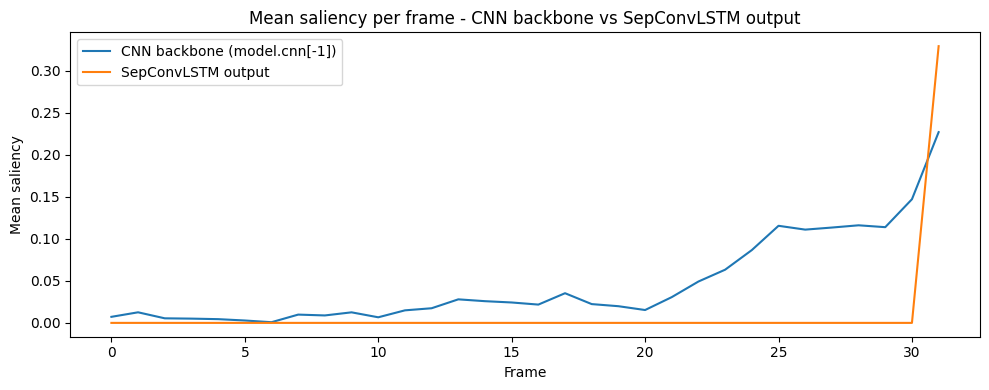

In [16]:
# per-frame mean importance - a more direct test of the last-frame-bias
# hypothesis than eyeballing the two grids above
heatmap_mean_per_frame = heatmap.squeeze(0).mean(dim=(1, 2)).cpu().numpy()
heatmap_sepconv_mean_per_frame = heatmap_sepconv.squeeze(0).mean(dim=(1, 2)).cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(heatmap_mean_per_frame, label="CNN backbone (model.cnn[-1])")
plt.plot(heatmap_sepconv_mean_per_frame, label="SepConvLSTM output")
plt.xlabel("Frame")
plt.ylabel("Mean saliency")
plt.title("Mean saliency per frame - CNN backbone vs SepConvLSTM output")
plt.legend()
plt.tight_layout()
plt.show()